# Day 4 - Fund Performance Analytics

This notebook calculates daily returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, and generates a composite scorecard.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
funds = pd.read_csv('data/01_fund_master.csv')
nav = pd.read_csv('data/02_nav_history.csv', parse_dates=['date'])
benchmarks = pd.read_csv('data/10_benchmark_indices.csv', parse_dates=['date'])

# Sort data
nav = nav.sort_values(by=['amfi_code', 'date'])
benchmarks = benchmarks.sort_values(by=['index_name', 'date'])


## 1. Compute Daily Returns
Calculate `nav_t / nav_{t-1} - 1` for all 40 schemes and validate distribution.

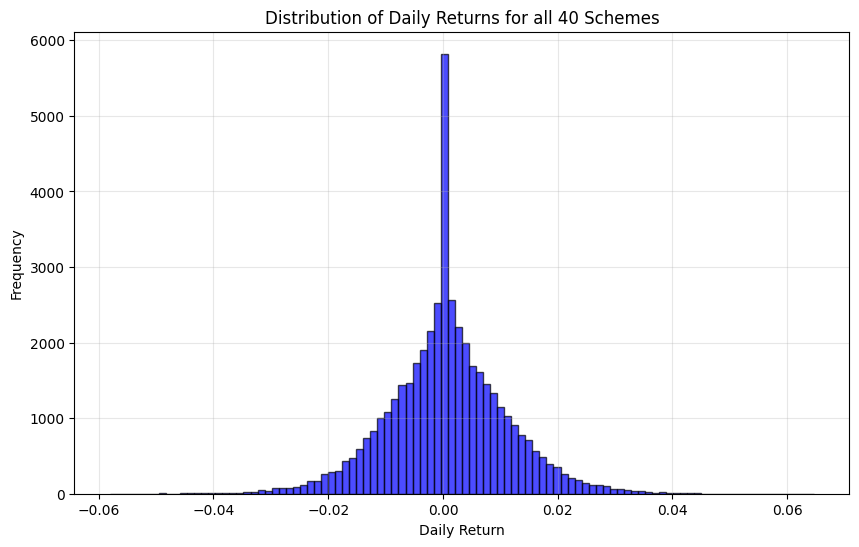

In [2]:

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# Plot distribution to validate
plt.figure(figsize=(10, 6))
plt.hist(nav['daily_return'].dropna(), bins=100, alpha=0.7, color='blue', edgecolor='black')
plt.title('Distribution of Daily Returns for all 40 Schemes')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()


## 2. Compute CAGR (1yr, 3yr, 5yr)
Formula: `(NAV_end / NAV_start) ^ (1/n) - 1`

In [3]:

latest_date = nav['date'].max()

def calc_cagr(df_group, years):
    start_date = latest_date - pd.DateOffset(years=years)
    df_period = df_group[df_group['date'] >= start_date]
    if len(df_period) < 20:  # Require some minimum data points
        return np.nan
    start_nav = df_period.iloc[0]['nav']
    end_nav = df_period.iloc[-1]['nav']
    if start_nav <= 0: return np.nan
    actual_years = (df_period.iloc[-1]['date'] - df_period.iloc[0]['date']).days / 365.25
    if actual_years == 0: return np.nan
    return (end_nav / start_nav) ** (1 / actual_years) - 1

cagr_results = []
for amfi_code, group in nav.groupby('amfi_code'):
    fund_name = funds[funds['amfi_code'] == amfi_code]['scheme_name'].values[0]
    cagr_1y = calc_cagr(group, 1)
    cagr_3y = calc_cagr(group, 3)
    cagr_5y = calc_cagr(group, 5)
    cagr_results.append({
        'amfi_code': amfi_code,
        'scheme_name': fund_name,
        'CAGR_1yr': cagr_1y,
        'CAGR_3yr': cagr_3y,
        'CAGR_5yr': cagr_5y
    })

cagr_df = pd.DataFrame(cagr_results)
cagr_df.head()


,amfi_code,scheme_name,CAGR_1yr,CAGR_3yr,CAGR_5yr
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.022258,0.012924,0.026371
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.037076,0.039155,0.044582
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532772,0.324340,0.301232
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.479638,0.289602,0.235384
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.240003,-0.041515,0.079388


## 3. Sharpe Ratio and Sortino Ratio
`Sharpe = (Rp - Rf) / Std(Rp) * sqrt(252)`
`Sortino = (Rp - Rf) / Downside_Std(Rp) * sqrt(252)`

In [4]:

rf_annual = 0.065
rf_daily = (1 + rf_annual) ** (1/252) - 1

ratio_results = []
for amfi_code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    if len(returns) < 50:
        continue
    
    # Rp = mean daily return
    mean_return = returns.mean()
    std_return = returns.std()
    
    if std_return > 0:
        sharpe = (mean_return - rf_daily) / std_return * np.sqrt(252)
    else:
        sharpe = np.nan
        
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std()
    
    if downside_std > 0:
        sortino = (mean_return - rf_daily) / downside_std * np.sqrt(252)
    else:
        sortino = np.nan
        
    ratio_results.append({
        'amfi_code': amfi_code,
        'Sharpe_Ratio': sharpe,
        'Sortino_Ratio': sortino
    })

ratio_df = pd.DataFrame(ratio_results)
ratio_df['Sharpe_Rank'] = ratio_df['Sharpe_Ratio'].rank(ascending=False)
ratio_df.head()


,amfi_code,Sharpe_Ratio,Sortino_Ratio,Sharpe_Rank
0,100016,-0.187650,-0.326892,36.0
1,100025,-0.515438,-0.856030,40.0
2,100033,1.104352,1.846950,7.0
3,101206,1.041061,1.823822,9.0
4,101207,0.170481,0.289943,29.0


## 4. Alpha and Beta
OLS regression of fund returns on Nifty 100 returns using `scipy.stats.linregress`.
Alpha = intercept * 252

In [5]:

nifty100 = benchmarks[benchmarks['index_name'] == 'NIFTY100'].copy()
nifty100['nifty100_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna(subset=['nifty100_return'])

alpha_beta_results = []
for amfi_code, group in nav.groupby('amfi_code'):
    df_merged = pd.merge(group, nifty100[['date', 'nifty100_return']], on='date', how='inner').dropna(subset=['daily_return', 'nifty100_return'])
    if len(df_merged) < 50:
        continue
        
    slope, intercept, r_value, p_value, std_err = stats.linregress(df_merged['nifty100_return'], df_merged['daily_return'])
    
    alpha_annualized = intercept * 252
    beta = slope
    
    # Tracking Error vs Nifty 100 (for general info, though the prompt asked for top 5 vs benchmarks later)
    # The prompt actually asks for Tracking error later, but we can compute it here for Nifty 100
    tracking_error = np.std(df_merged['daily_return'] - df_merged['nifty100_return']) * np.sqrt(252)
    
    alpha_beta_results.append({
        'amfi_code': amfi_code,
        'Alpha': alpha_annualized,
        'Beta': beta,
        'Tracking_Error_N100': tracking_error
    })

ab_df = pd.DataFrame(alpha_beta_results)
ab_df.to_csv('alpha_beta.csv', index=False)
print("Saved alpha_beta.csv")
ab_df.head()


Saved alpha_beta.csv


,amfi_code,Alpha,Beta,Tracking_Error_N100
0,100016,0.037476,-0.058268,0.199197
1,100025,0.042818,0.001158,0.134477
2,100033,0.271954,0.005104,0.228600
3,101206,0.213998,0.021086,0.192623
4,101207,0.108971,-0.065289,0.291990


## 5. Maximum Drawdown
`min(NAV / running_max - 1)` for each fund.

In [6]:

dd_results = []
for amfi_code, group in nav.groupby('amfi_code'):
    group = group.copy()
    group['running_max'] = group['nav'].cummax()
    group['drawdown'] = group['nav'] / group['running_max'] - 1
    
    max_dd = group['drawdown'].min()
    worst_idx = group['drawdown'].idxmin()
    
    if pd.isna(worst_idx):
        continue
        
    worst_date = group.loc[worst_idx, 'date']
    
    # find the peak before the worst date
    peak_date = group[group['date'] <= worst_date]['running_max'].idxmax()
    if pd.isna(peak_date):
        peak_date_val = None
    else:
        peak_date_val = group.loc[peak_date, 'date']
        
    dd_results.append({
        'amfi_code': amfi_code,
        'Max_Drawdown': max_dd,
        'Worst_DD_Peak_Date': peak_date_val,
        'Worst_DD_Bottom_Date': worst_date
    })

dd_df = pd.DataFrame(dd_results)
dd_df.head()


,amfi_code,Max_Drawdown,Worst_DD_Peak_Date,Worst_DD_Bottom_Date
0,100016,-0.247344,2022-03-30,2022-09-15
1,100025,-0.043083,2023-05-23,2023-07-28
2,100033,-0.162172,2022-03-11,2022-05-12
3,101206,-0.112916,2023-04-24,2023-07-05
4,101207,-0.354469,2024-11-21,2026-05-11


## 6. Fund Scorecard (0-100)
Composite: 30% * 3yr return rank + 25% * Sharpe rank + 20% * Alpha rank + 15% * expense ratio rank (inverse) + 10% * max DD rank (inverse)

In [7]:

# Merge all metrics
scorecard_df = funds[['amfi_code', 'scheme_name', 'expense_ratio_pct']].copy()
scorecard_df = scorecard_df.merge(cagr_df[['amfi_code', 'CAGR_3yr']], on='amfi_code', how='left')
scorecard_df = scorecard_df.merge(ratio_df[['amfi_code', 'Sharpe_Ratio']], on='amfi_code', how='left')
scorecard_df = scorecard_df.merge(ab_df[['amfi_code', 'Alpha']], on='amfi_code', how='left')
scorecard_df = scorecard_df.merge(dd_df[['amfi_code', 'Max_Drawdown']], on='amfi_code', how='left')

# Drop any rows with too many missing values (if any)
scorecard_df = scorecard_df.dropna(subset=['CAGR_3yr', 'Sharpe_Ratio', 'Alpha', 'Max_Drawdown', 'expense_ratio_pct'])

# To rank into a 0-100 score, we will use percentile ranking. 
# For "rank", highest value is best (100) for returns, sharpe, alpha.
# For "inverse", lowest value is best (100) for expense ratio, max drawdown (which is negative, so closest to 0 is highest value, so we actually want highest Max_Drawdown to be best. Wait, if max DD is -50% and -10%, -10% is better. So higher Max_Drawdown value is better. Or if we use absolute max DD, lower is better. Since max_dd is negative, the highest value (closest to 0) is the best. So percentile rank directly works.)
# Expense ratio: lower is better, so inverse percentile (1 - pct)

scorecard_df['3yr_ret_score'] = scorecard_df['CAGR_3yr'].rank(pct=True) * 100
scorecard_df['sharpe_score'] = scorecard_df['Sharpe_Ratio'].rank(pct=True) * 100
scorecard_df['alpha_score'] = scorecard_df['Alpha'].rank(pct=True) * 100
scorecard_df['expense_score'] = scorecard_df['expense_ratio_pct'].rank(ascending=False, pct=True) * 100 # lower expense -> higher score
scorecard_df['max_dd_score'] = scorecard_df['Max_Drawdown'].rank(pct=True) * 100 # highest (closest to 0) -> higher score

# Composite score
scorecard_df['Score'] = (
    0.30 * scorecard_df['3yr_ret_score'] + 
    0.25 * scorecard_df['sharpe_score'] + 
    0.20 * scorecard_df['alpha_score'] + 
    0.15 * scorecard_df['expense_score'] + 
    0.10 * scorecard_df['max_dd_score']
)

scorecard_df = scorecard_df.sort_values(by='Score', ascending=False)
scorecard_df.to_csv('fund_scorecard.csv', index=False)
print("Saved fund_scorecard.csv")
scorecard_df.head()


Saved fund_scorecard.csv


,amfi_code,scheme_name,expense_ratio_pct,CAGR_3yr,Sharpe_Ratio,Alpha,Max_Drawdown,3yr_ret_score,sharpe_score,alpha_score,expense_score,max_dd_score,Score
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.46,0.339920,1.462504,0.269838,-0.112657,97.5,100.0,85.0,45.0,82.5,86.25
12,120505,ICICI Pru Midcap Fund - Regular - Growth,1.36,0.317692,1.190559,0.292636,-0.181885,90.0,90.0,95.0,65.0,40.0,82.25
22,120843,Kotak Flexicap Fund - Regular - Growth,1.45,0.295751,1.319442,0.273305,-0.129740,85.0,97.5,90.0,47.5,70.0,82.00
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38,0.324340,1.104352,0.271954,-0.162172,92.5,85.0,87.5,60.0,52.5,80.75
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.80,0.324789,1.040569,0.211948,-0.125883,95.0,77.5,70.0,72.5,72.5,80.00


## 7. Benchmark Comparison Chart
Plot top 5 funds vs Nifty 50 and Nifty 100 over 3 years. Compute tracking error.

Saved benchmark_comparison_chart.png


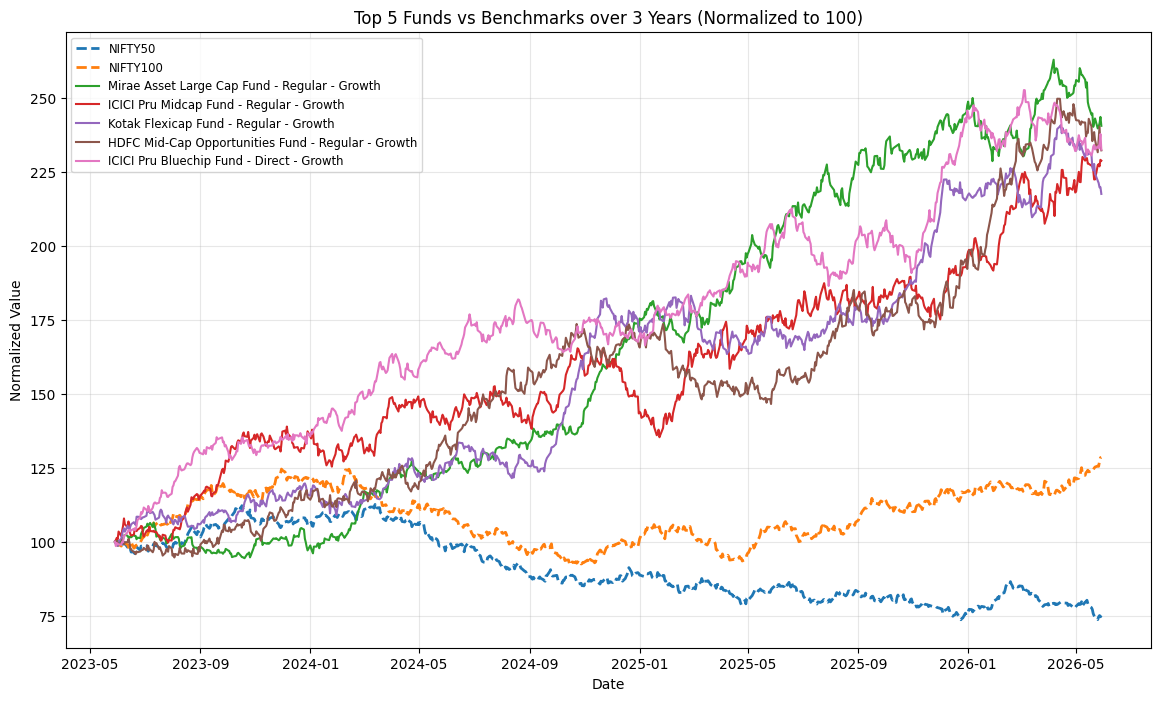

Tracking Errors for Top 5 Funds vs NIFTY50:


,Fund,TE_vs_NIFTY50
0,Mirae Asset Large Cap Fund - Regular - Growth,0.191695
1,ICICI Pru Midcap Fund - Regular - Growth,0.228165
2,Kotak Flexicap Fund - Regular - Growth,0.204816
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.227935
4,ICICI Pru Bluechip Fund - Direct - Growth,0.188240


In [8]:

# Get top 5 funds
top_5_amfi = scorecard_df.head(5)['amfi_code'].tolist()

# Define 3 years ago date
start_date_3y = latest_date - pd.DateOffset(years=3)

plt.figure(figsize=(14, 8))

# Plot benchmarks
for bench_name in ['NIFTY50', 'NIFTY100']:
    bench_data = benchmarks[(benchmarks['index_name'] == bench_name) & (benchmarks['date'] >= start_date_3y)]
    if not bench_data.empty:
        # Normalize to 100
        start_val = bench_data.iloc[0]['close_value']
        plt.plot(bench_data['date'], bench_data['close_value'] / start_val * 100, label=bench_name, linewidth=2, linestyle='--')

# Plot top 5 funds
tracking_errors = []
nifty50_returns = benchmarks[benchmarks['index_name'] == 'NIFTY50'][['date', 'close_value']].rename(columns={'close_value': 'nifty50'})
nifty50_returns['nifty50_ret'] = nifty50_returns['nifty50'].pct_change()

for amfi in top_5_amfi:
    fund_name = funds[funds['amfi_code'] == amfi]['scheme_name'].values[0]
    fund_data = nav[(nav['amfi_code'] == amfi) & (nav['date'] >= start_date_3y)]
    if not fund_data.empty:
        start_val = fund_data.iloc[0]['nav']
        plt.plot(fund_data['date'], fund_data['nav'] / start_val * 100, label=fund_name, linewidth=1.5)
        
        # Calculate Tracking Error against Nifty 50
        merged = pd.merge(fund_data, nifty50_returns, on='date', how='inner')
        te = np.std(merged['daily_return'] - merged['nifty50_ret']) * np.sqrt(252)
        tracking_errors.append({'Fund': fund_name, 'TE_vs_NIFTY50': te})

plt.title('Top 5 Funds vs Benchmarks over 3 Years (Normalized to 100)')
plt.xlabel('Date')
plt.ylabel('Normalized Value')
plt.legend(loc='best', fontsize='small')
plt.grid(True, alpha=0.3)
plt.savefig('benchmark_comparison_chart.png', dpi=300, bbox_inches='tight')
print("Saved benchmark_comparison_chart.png")
plt.show()

print("Tracking Errors for Top 5 Funds vs NIFTY50:")
te_df = pd.DataFrame(tracking_errors)
te_df
